## Expressões Regulares

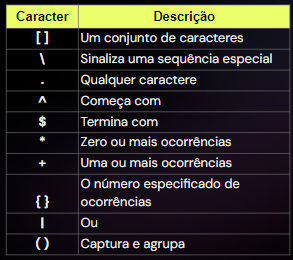

* \d = dígito
* \w = caractere alfanumérico (letras, número e underscore _ )
* \s = espaço em branco
* ^ = Começa com ou negação

In [3]:
texto = """
O telefone da farmácia é 3000-3232, mas eles só atendem até as 18h em dias úteis.
Se precisar entrar em contato fora desse horário, você pode enviar uma mensagem para o celular de emergência no número (11) 98765-4321.
Importante ressaltar que hoje, 27/02/24, é o último dia para aproveitar a promoção especial de medicamentos que começou em 01/02/2024.
Não esqueça de apresentar seu CPF na hora da compra, o número 1.78923.456-00 não é um exemplo válido.
Exemplos de CPFs válidos são: 123.456.789-09 e 987.654.321-00.
Para mais informações, acesse nosso site ou entre em contato diretamente.

1/1/15
(12)99765-4321
(12)9765-4321
teste_undescore
00-
00+222

"""

**Número de Telefone:**

\(\d{2}\)\d{4}-\d{4}

* \( e \): Captura os parênteses.

* \d{2}: Captura dois dígitos para o DDD.

* \d{4}: Captura quatro dígitos do número.

* -: Captura o hífen no número de telefone.

Mais geral:

\(\d{2}\)\s*\d{4,5}-\d{4}


----

**Caracteres Especiais:**

[^\w\s]

* [^]:  ^ dentro dos colchetes captura tudo exceto os caracteres especificados nos []
* \w: Captura qualquer caractere alfanumérico (letras e números) e o underscore _
* \s: Captura qualquer espaço em branco (incluindo espaços, tabs, etc.)





### Regex no python:

In [2]:
import re

#### findall

In [6]:
# Regex para capturar datas de aniversário
pattern = r'\d{1,2}/\d{1,2}/\d{2,4}'
re.findall(pattern,texto)

['(11) 98765-4321', '(12)99765-4321', '(12)9765-4321']

In [8]:
# Regex para capturar CPFs no formato XXX.XXX.XXX-XX
pattern = r"\d{3}\.\d{3}\.\d{3}-\d{2}"

# Encontrar todos os CPFs no texto
cpfs = re.findall(pattern, texto)
cpfs

['123.456.789-09', '987.654.321-00']

In [9]:
# Regex para capturar e-mails

texto_email = "Contate-nos em email.exemplo@dominio.com, Suporte_123@empresa.org ou info-info@sub.dominio.net"

pattern = r'[a-zA-Z0-9._+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'

# Encontrar todos os e-mails no texto
emails = re.findall(pattern, texto_email)
emails

['email.exemplo@dominio.com',
 'Suporte_123@empresa.org',
 'info-info@sub.dominio.net']

[a-zA-Z0-9._%+-]+: Captura a parte local do e-mail (antes do @), que pode conter letras, números, pontos (.), underscores (_),  mais (+), e hífens (-). O mais indica 1 ou mais caracteres.

@: Captura o símbolo @.

[a-zA-Z0-9.-]+: Captura o domínio e subdomínio, que pode conter letras, números, pontos (.) e hífens (-).

\.: Captura o ponto literal . que separa o domínio do TLD.

[a-zA-Z]{2,}: Captura o TLD (Top-Level Domain), que pode ser .com, .org, .net, etc., e deve ter pelo menos dois caracteres

#### match

Verifica se o padrão corresponde ao **INÍCIO** da string

In [13]:
pattern = r"\d{3}\.\d{3}\.\d{3}-\d{2}"

verificacao = re.match(pattern,texto)
print(verificacao)

None


In [21]:
txt = "123.456.789-09 é um formato de CPF"
verificacao = re.match(pattern,txt)
verificacao

<re.Match object; span=(0, 14), match='123.456.789-09'>

In [22]:
if verificacao:
    print('encontrado')
else:
    print('não encontrado no início')

encontrado


#### search

Procura pelo padrão em qualquer parte da string e retorna o primeiro match encontrado

In [34]:
txt = "A sequência 123.456.789-19 é um formato de CPF. 987.456.789-19"

pattern = r"\d{3}\.\d{3}\.\d{3}-\d{2}"
verificacao = re.search(pattern, txt)


In [35]:
if verificacao:
    print(f'O CPF {verificacao.group()} foi encontrado')

O CPF 123.456.789-19 foi encontrado


## Web Scraping

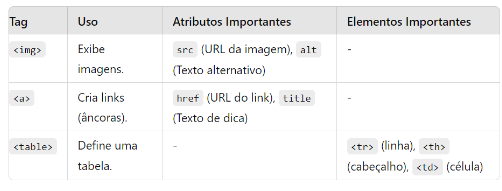

In [ ]:
#!pip install requests beautifulsoup4

In [37]:
import requests
from bs4 import BeautifulSoup

In [38]:
url = 'https://pt.wikipedia.org/wiki/Uberl%C3%A2ndia'  
response = requests.get(url)

if response.status_code == 200:
    print("Requisição bem-sucedida!")
else:
    print(f"Erro na requisição: {response.status_code}")


Requisição bem-sucedida!


In [40]:
soup = BeautifulSoup(response.text, 'html.parser')
#soup

In [41]:
tabela = soup.find('table')  # Encontra a primeira tabela na página
linhas = tabela.find_all('tr')  # Encontra todas as linhas da tabela

for linha in linhas:
    colunas = linha.find_all('td')  # Encontra todas as colunas em uma linha
    dados = [coluna.text for coluna in colunas]  # Extrai o texto de cada coluna
    print(dados)


['Uberlândia']
['Uberlândia']
[]
['']
['Do topo, da esquerda para a direita: panorama da cidade; Praia Clube; Igreja Nossa Senhora do Rosário; Parque do Sabiá e Mercado Municipal de Uberlândia.']
[]
['\n Bandeira\n\n\n', ' Bandeira']
[' Bandeira']
['Hino\n']
['Gentílico\n', 'uberlandense[1]\n']
[]
['']
['Localização de Uberlândia em Minas GeraisLocalização de Uberlândia em Minas Gerais\n']
['\nUberlândiaLocalização de Uberlândia no Brasil\n']
['\nMapa de Uberlândia']
['Coordenadas\n', '18° 55′ 08″ S, 48° 16′ 37″ O\n']
['País\n', 'Brasil\n']
['Unidade federativa\n', 'Minas Gerais\n']
['Municípios limítrofes\n', 'Sul: Veríssimo;Sudeste: Uberaba;Norte: Araguari;Leste: Indianópolis;Oeste: Monte Alegre de Minas;Noroeste: Tupaciguara;Sudoeste: Prata\n']
['Distância até a capital\n', '537\xa0km[2]\n']
[]
['Fundação\n', '31 de agosto de 1888 (136\xa0anos)\n']
[]
['Prefeito(a)\n', 'Odelmo Leão Carneiro Sobrinho (PP, 2021–2024)\n']
[]
['Área total [1]\n', '4\xa0115,206\xa0km²\n']
['População tot

In [42]:
# Formatando e imprimindo os dados extraídos
for linha in linhas:
    colunas = linha.find_all('td')  # Encontra todas as colunas na linha
    dados = [coluna.text.strip() for coluna in colunas]  # Extrai e limpa o texto de cada coluna
    
    # Verifica se a linha contém dados para exibir de forma organizada
    if len(dados) > 1:
        print(f"{dados[0]:<30}: {dados[1]}")
    elif len(dados) == 1:
        print(f"{dados[0]:<30}")
    else:
        print()  # Linha vazia

Uberlândia                    
Uberlândia                    

                              
Do topo, da esquerda para a direita: panorama da cidade; Praia Clube; Igreja Nossa Senhora do Rosário; Parque do Sabiá e Mercado Municipal de Uberlândia.

Bandeira                      : Bandeira
Bandeira                      
Hino                          
Gentílico                     : uberlandense[1]

                              
Localização de Uberlândia em Minas GeraisLocalização de Uberlândia em Minas Gerais
UberlândiaLocalização de Uberlândia no Brasil
Mapa de Uberlândia            
Coordenadas                   : 18° 55′ 08″ S, 48° 16′ 37″ O
País                          : Brasil
Unidade federativa            : Minas Gerais
Municípios limítrofes         : Sul: Veríssimo;Sudeste: Uberaba;Norte: Araguari;Leste: Indianópolis;Oeste: Monte Alegre de Minas;Noroeste: Tupaciguara;Sudoeste: Prata
Distância até a capital       : 537 km[2]

Fundação                      : 31 de agosto de 1888 

## Exercícios